In [16]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
df=pd.read_csv('customer_shopping_behavior.csv')
df

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,2-Day Shipping,No,No,32,Venmo,Weekly
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Standard,No,No,24,Venmo,Quarterly
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,Express,No,No,24,Venmo,Weekly


In [5]:
df

,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
Customer ID,,,,,,,,,,,,,,,,,
1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,2-Day Shipping,No,No,32,Venmo,Weekly
3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Standard,No,No,24,Venmo,Quarterly


In [7]:
df['Gender'].value_counts()

Gender
Male      2652
Female    1248
Name: count, dtype: int64

<Axes: xlabel='Gender', ylabel='count'>

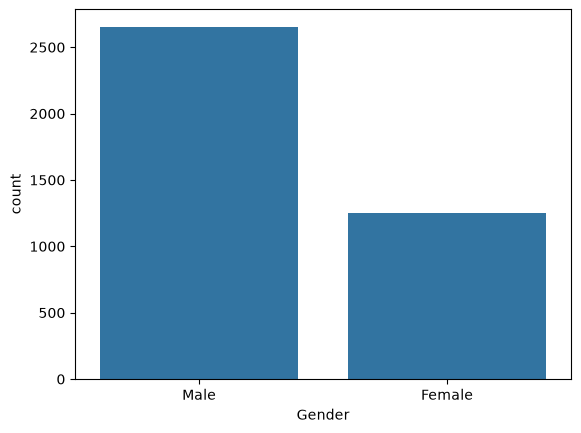

In [9]:
sns.countplot(x='Gender',
    data=df)
    


<Axes: xlabel='age', ylabel='purchase amount (usd)'>

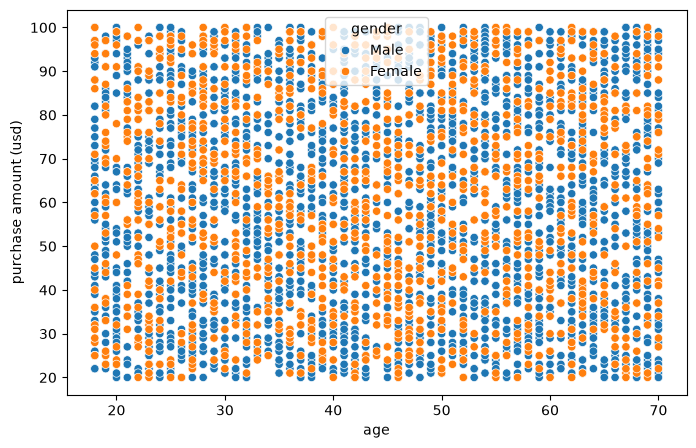

In [19]:
plt.figure(figsize=(8, 5))

sns.scatterplot(x='age',
                y='purchase amount (usd)',
                data=df,
                hue='gender')


In [13]:
df.columns = df.columns.str.lower().str.strip()
df.columns

Index(['age', 'gender', 'item purchased', 'category', 'purchase amount (usd)',
       'location', 'size', 'color', 'season', 'review rating',
       'subscription status', 'shipping type', 'discount applied',
       'promo code used', 'previous purchases', 'payment method',
       'frequency of purchases'],
      dtype='str')

In [20]:
df.isna().sum()

age                        0
gender                     0
item purchased             0
category                   0
purchase amount (usd)      0
location                   0
size                       0
color                      0
season                     0
review rating             37
subscription status        0
shipping type              0
discount applied           0
promo code used            0
previous purchases         0
payment method             0
frequency of purchases     0
dtype: int64

In [22]:
mean_rating = df["review rating"].median()

df["review rating"] = df["review rating"].fillna(mean_rating,inplace=True)

C:\Users\bansa\AppData\Local\Temp\ipykernel_37592\2864685258.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["review rating"] = df["review rating"].fillna(mean_rating,inplace=True)


In [24]:
df.to_csv('your_file.csv', index=False)

In [25]:
df['gender'].value_counts(normalize=True)*100

gender
Male      68.0
Female    32.0
Name: proportion, dtype: float64

In [27]:
avg_sales_gender=df.groupby('gender')['purchase amount (usd)'].mean().reset_index()
avg_sales_gender

,gender,purchase amount (usd)
0,Female,60.249199
1,Male,59.536199


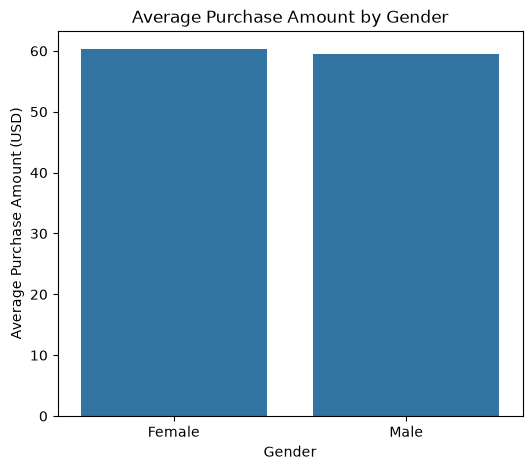

In [34]:
plt.figure(figsize=(6,5))
sns.barplot(
    x='gender',
    y='purchase amount (usd)',
    data=avg_sales_gender
)

plt.title('Average Purchase Amount by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Purchase Amount (USD)')

plt.show()



In [36]:
total_revenue_gender=df.groupby('gender')['purchase amount (usd)'].sum().reset_index()
total_revenue_gender

,gender,purchase amount (usd)
0,Female,75191
1,Male,157890


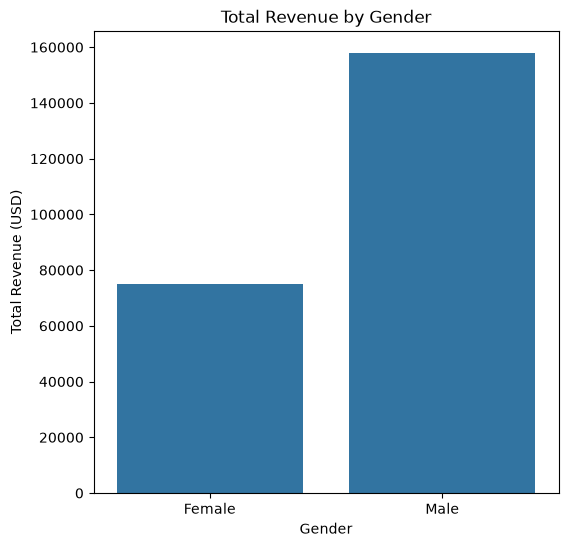

In [38]:
plt.figure(figsize=(6,6))
sns.barplot(x='gender',y='purchase amount (usd)',data=total_revenue_gender)
plt.title('Total Revenue by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Revenue (USD)')
plt.show()


In [39]:
gender_category = pd.crosstab(
    df['gender'],
    df['category']
)

gender_category

category,Accessories,Clothing,Footwear,Outerwear
gender,,,,
Female,392,556,199,101
Male,848,1181,400,223


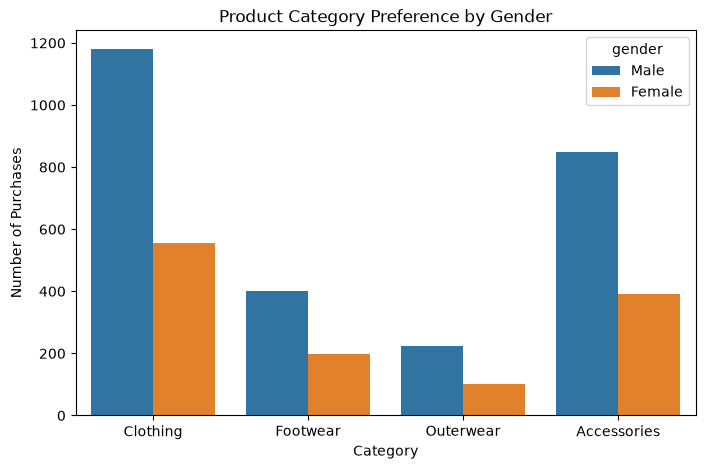

In [40]:
plt.figure(figsize=(8, 5))

sns.countplot(
    x='category',
    hue='gender',
    data=df
)

plt.title('Product Category Preference by Gender')
plt.xlabel('Category')
plt.ylabel('Number of Purchases')

plt.show()

In [41]:
gender_category_percentage = pd.crosstab(
    df['gender'],
    df['category'],
    normalize='index'
) * 100

gender_category_percentage

category,Accessories,Clothing,Footwear,Outerwear
gender,,,,
Female,31.410256,44.551282,15.945513,8.092949
Male,31.975867,44.532428,15.082956,8.408748
